In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
df = pd.read_csv('diabetes.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (768, 9)

Column Names:
 ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe().T

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
# These columns cannot be zero medically
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace zeros with NaN so we can handle them properly
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Now check how many actual missing values we have
print("Missing values after replacing zeros:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing values: 652


In [ ]:
# Fill missing values with median for each column
for col in cols_with_zeros:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: filled with median = {median_value}")

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")

Glucose: filled with median = 117.0
BloodPressure: filled with median = 72.0
SkinThickness: filled with median = 29.0
Insulin: filled with median = 125.0
BMI: filled with median = 32.3

Missing values remaining: 0


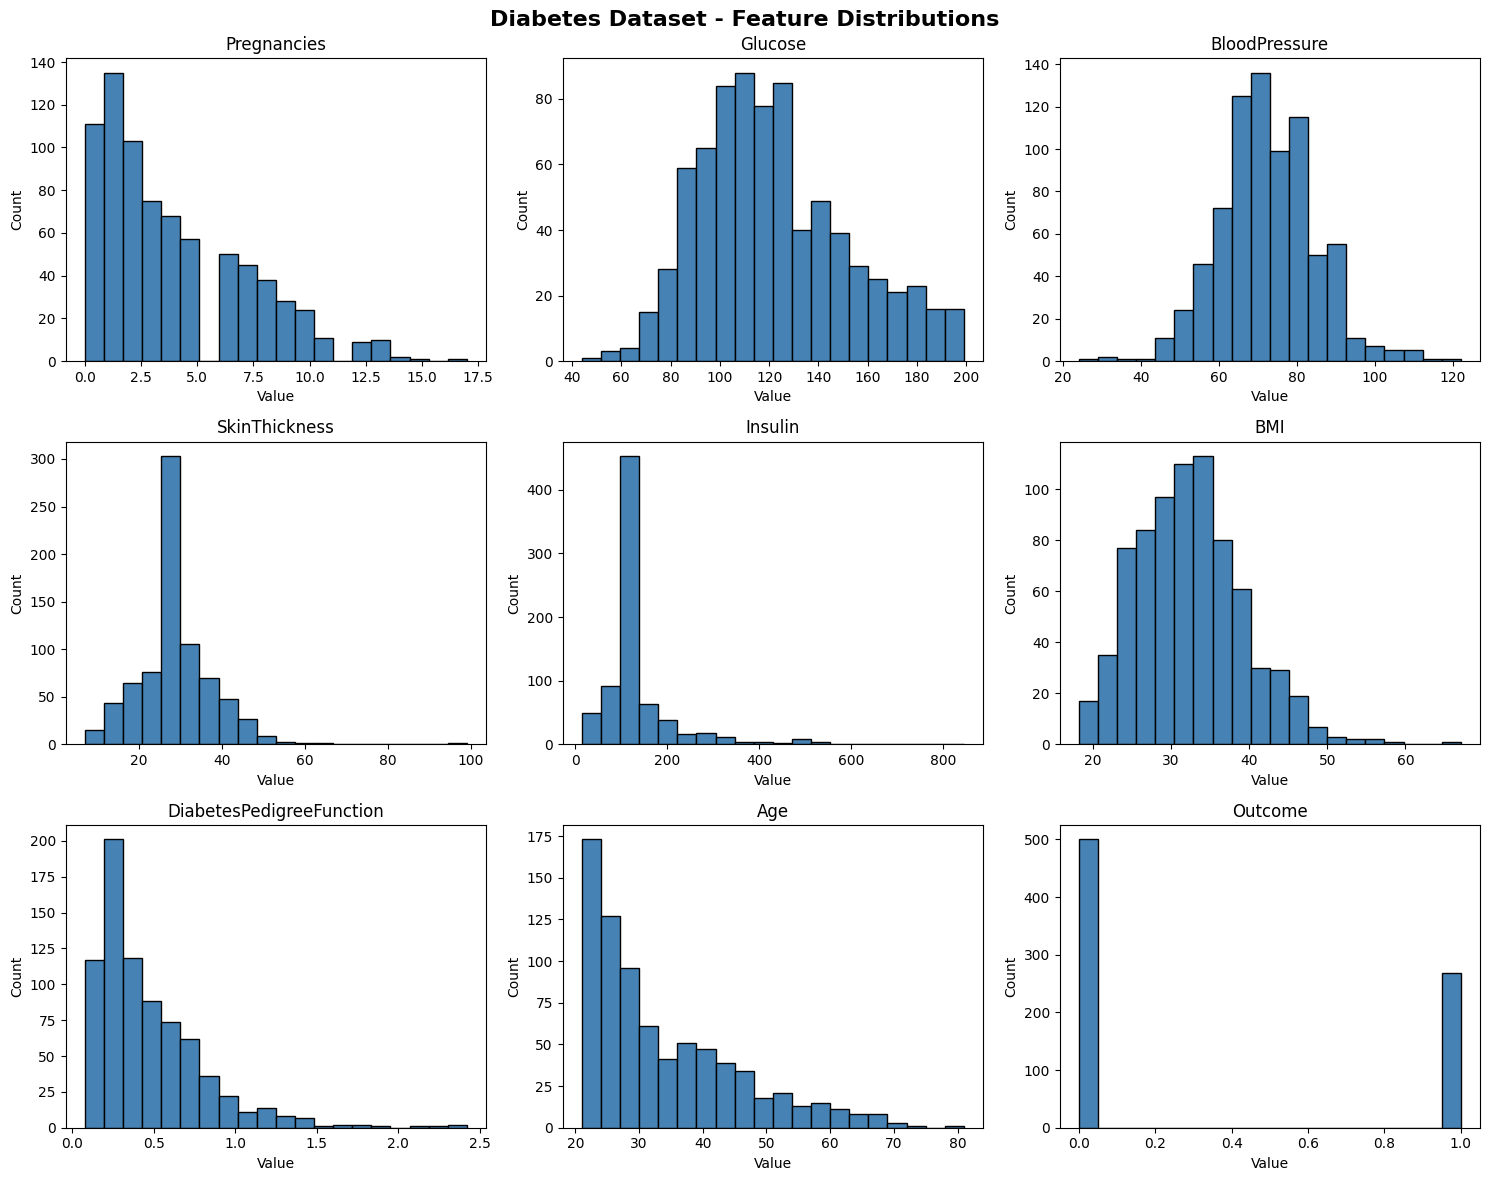

Chart saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Diabetes Dataset - Feature Distributions',
             fontsize=16, fontweight='bold')

features = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age', 'Outcome']

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    axes[row, col].hist(df[feature], bins=20,
                        color='steelblue', edgecolor='black')
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Count')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

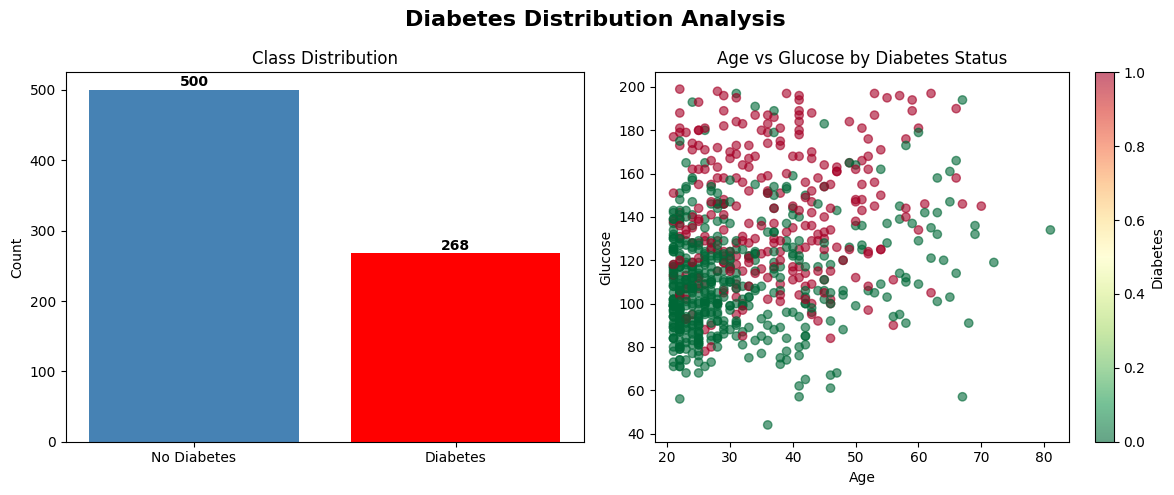

No Diabetes: 500 patients
Diabetes: 268 patients


In [ ]:
# Check class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Diabetes Distribution Analysis',
             fontsize=16, fontweight='bold')

# Chart 1 - Outcome distribution
outcome_counts = df['Outcome'].value_counts()
axes[0].bar(['No Diabetes', 'Diabetes'],
            outcome_counts.values,
            color=['steelblue', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Chart 2 - Glucose vs Age colored by outcome
scatter = axes[1].scatter(df['Age'], df['Glucose'],
                          c=df['Outcome'],
                          cmap='RdYlGn_r', alpha=0.6)
axes[1].set_title('Age vs Glucose by Diabetes Status')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Glucose')
plt.colorbar(scatter, ax=axes[1], label='Diabetes')

plt.tight_layout()
plt.savefig('diabetes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"No Diabetes: {outcome_counts[0]} patients")
print(f"Diabetes: {outcome_counts[1]} patients")

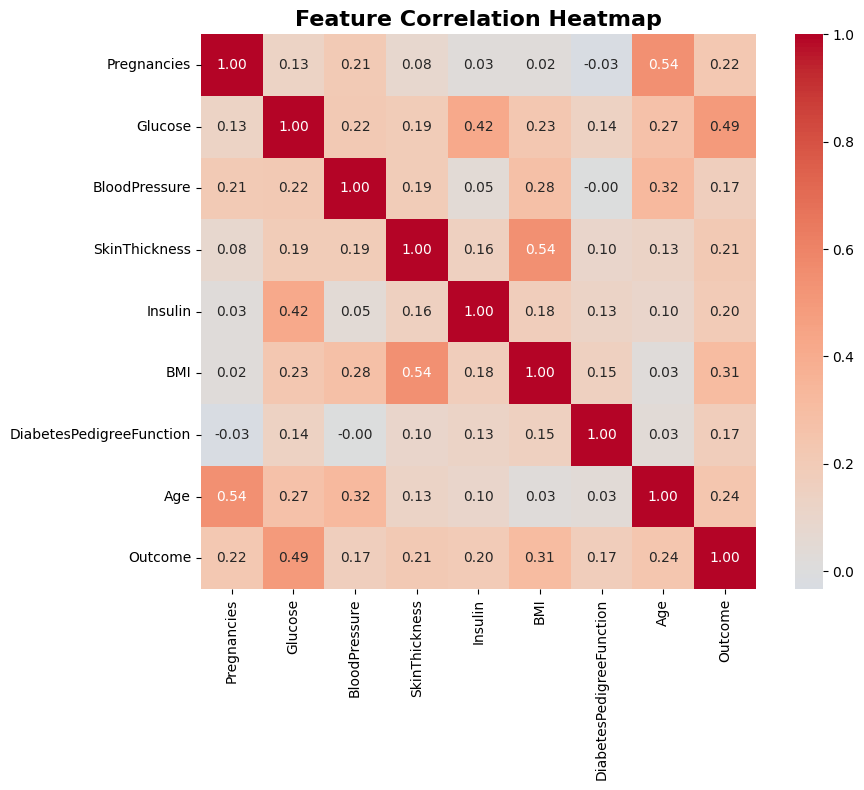

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Heatmap',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


# Split features and target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training set size: (614, 8)
Testing set size: (154, 8)

Class distribution in training set:
Outcome
0    400
1    214
Name: count, dtype: int64


In [ ]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))

Model Accuracy: 75.32%

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.82      0.80      0.81       100
    Diabetes       0.64      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.76      0.75      0.75       154



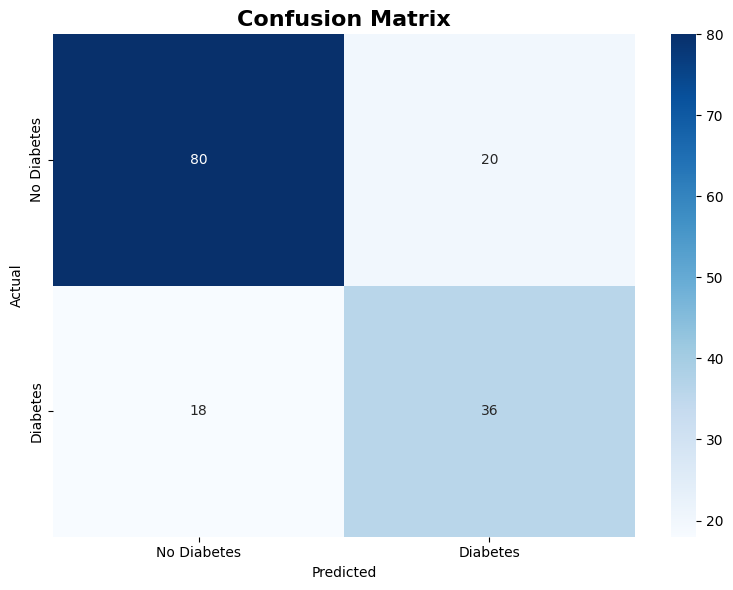

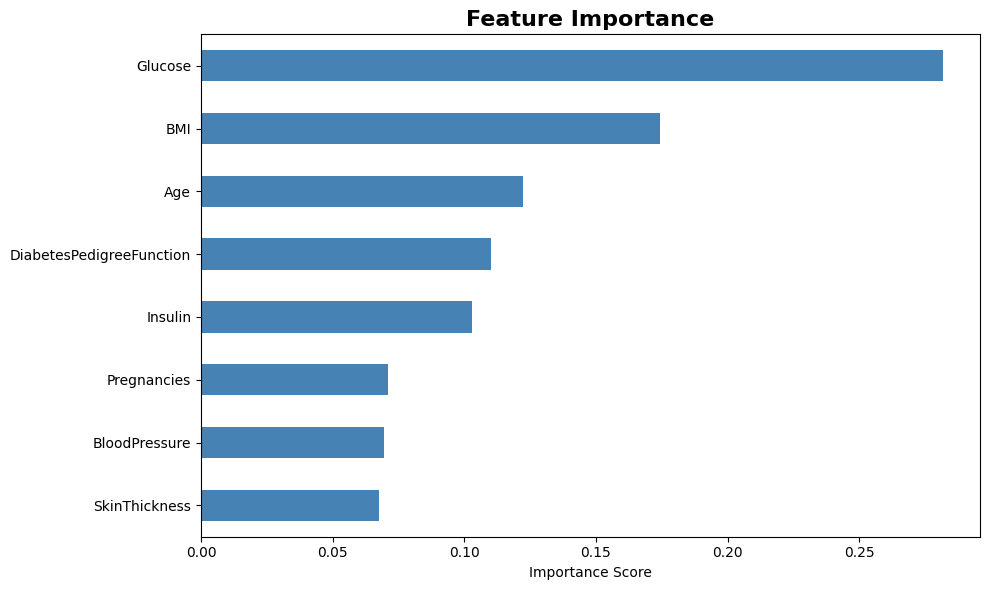

Feature Importance Scores:
Glucose                     0.281810
BMI                         0.174508
Age                         0.122245
DiabetesPedigreeFunction    0.110167
Insulin                     0.102999
Pregnancies                 0.070934
BloodPressure               0.069584
SkinThickness               0.067753
dtype: float64


In [ ]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=df.drop('Outcome', axis=1).columns
).sort_values(ascending=True)

feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature Importance Scores:")
print(feature_importance.sort_values(ascending=False))

In [ ]:
print("=" * 50)
print("DIABETES PREDICTION MODEL - KEY FINDINGS")
print("=" * 50)
print(f"Total patients analyzed: {len(df)}")
print(f"Model accuracy: 75.32%")
print(f"Most important predictor: Glucose (0.28)")
print(f"Second most important: BMI (0.17)")
print(f"Third most important: Age (0.12)")
print("\nClinical Insight:")
print("High glucose levels are the strongest predictor")
print("of diabetes, consistent with medical literature.")
print("=" * 50)

DIABETES PREDICTION MODEL - KEY FINDINGS
Total patients analyzed: 768
Model accuracy: 75.32%
Most important predictor: Glucose (0.28)
Second most important: BMI (0.17)
Third most important: Age (0.12)

Clinical Insight:
High glucose levels are the strongest predictor
of diabetes, consistent with medical literature.
